In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [28]:
data = pd.read_csv('diabetes.csv')
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [4]:
data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [5]:
data.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [6]:
data.duplicated().sum() 

np.int64(0)

In [7]:
data['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

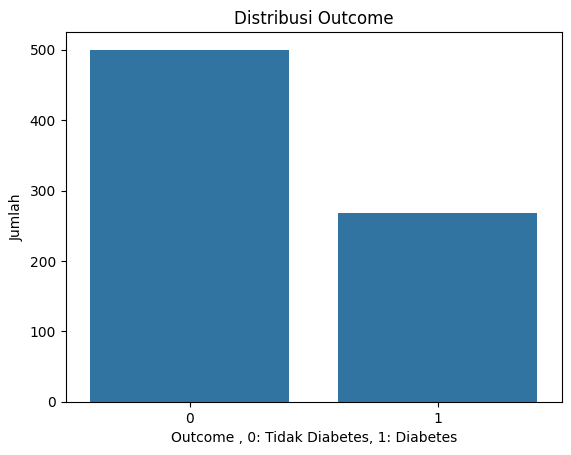

In [8]:
sns.countplot(x='Outcome', data=data)
plt.title('Distribusi Outcome')
plt.xlabel('Outcome , 0: Tidak Diabetes, 1: Diabetes')
plt.ylabel('Jumlah')
plt.show()

In [9]:
kolom_zero = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for kolom in kolom_zero:
    print(kolom, ':', (data[kolom] == 0).sum()) 

Glucose : 5
BloodPressure : 35
SkinThickness : 227
Insulin : 374
BMI : 11


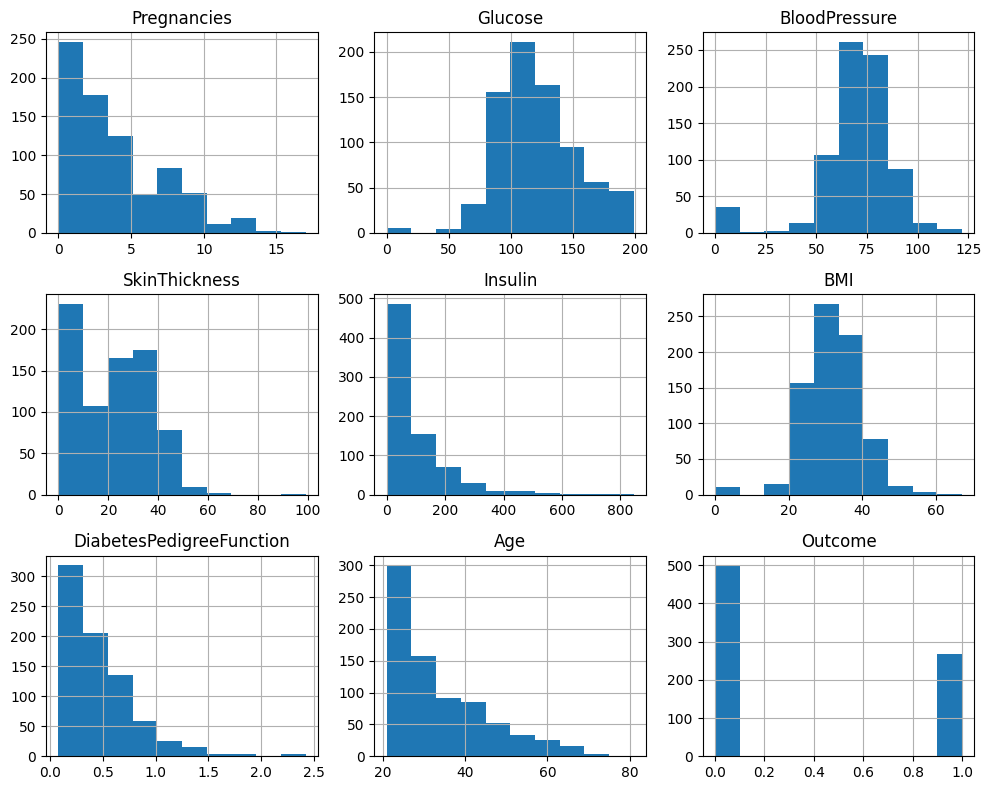

In [10]:
data.hist(figsize=(10, 8))
plt.tight_layout()
plt.show()

In [11]:
data[kolom_zero] = data[kolom_zero].replace(0, np.nan)    
data.isnull().sum()

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

In [12]:
# Mengisi NaN dengan median masing-masing kolom
for kolom in kolom_zero:
    data[kolom] = data[kolom].fillna(data[kolom].median())  

data.isnull().sum()    

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [13]:
data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.656250,72.386719,29.108073,140.671875,32.455208,0.471876,33.240885,0.348958
std,3.369578,30.438286,12.096642,8.791221,86.383060,6.875177,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,121.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.300000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


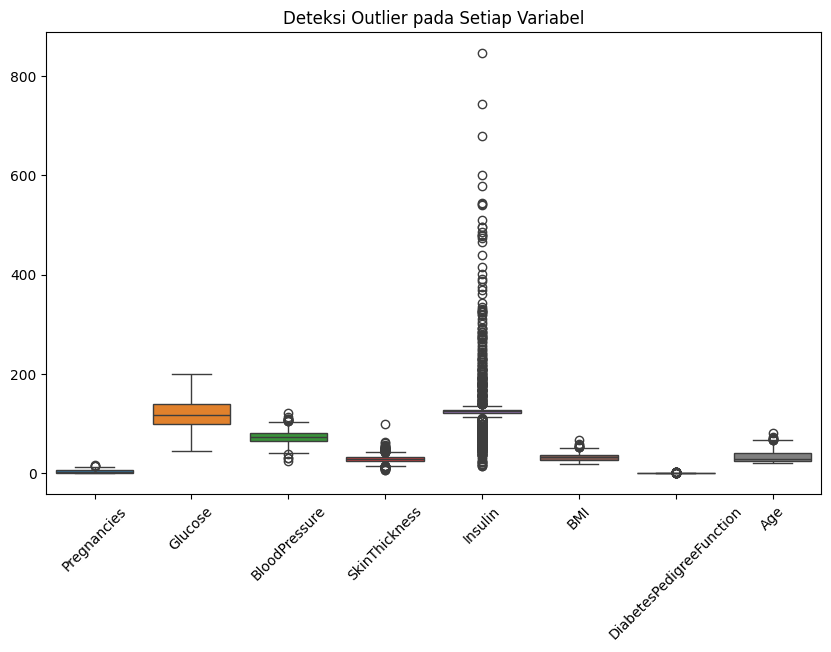

In [14]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=data.drop(columns='Outcome'))
plt.xticks(rotation=45)
plt.title("Deteksi Outlier pada Setiap Variabel")
plt.show()

In [16]:
from sklearn.preprocessing import RobustScaler

# Pisahkan fitur dan target
X = data.drop(columns='Outcome')
y = data['Outcome']

# Scaling data
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

# Melihat hasil scaling
print(X_scaled[:5])

[[ 0.6         0.7654321   0.          0.85714286  0.          0.14285714
   0.66535948  1.23529412]
 [-0.4        -0.79012346 -0.375       0.          0.         -0.62637363
  -0.05620915  0.11764706]
 [ 1.          1.62962963 -0.5         0.          0.         -0.98901099
   0.78300654  0.17647059]
 [-0.4        -0.69135802 -0.375      -0.85714286 -5.39130435 -0.46153846
  -0.5372549  -0.47058824]
 [-0.6         0.49382716 -2.          0.85714286  7.47826087  1.18681319
   5.00784314  0.23529412]]


In [17]:
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

X_scaled_df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,0.6,0.765432,0.000,0.857143,0.000000,0.142857,0.665359,1.235294
1,-0.4,-0.790123,-0.375,0.000000,0.000000,-0.626374,-0.056209,0.117647
2,1.0,1.629630,-0.500,0.000000,0.000000,-0.989011,0.783007,0.176471
3,-0.4,-0.691358,-0.375,-0.857143,-5.391304,-0.461538,-0.537255,-0.470588
4,-0.6,0.493827,-2.000,0.857143,7.478261,1.186813,5.007843,0.235294


In [19]:
from sklearn.model_selection import train_test_split

# Membagi data menjadi data training dan testing
X_train, X_test, y_train, y_test = train_test_split(X_scaled_df, y, test_size=0.2, random_state=42, stratify=y)

In [20]:
# Melihat ukuran data
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (614, 8)
X_test : (154, 8)
y_train: (614,)
y_test : (154,)


In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, recall_score, precision_score, f1_score

In [23]:
# Membuat model
logreg = LogisticRegression(random_state=42)
dt = DecisionTreeClassifier(random_state=42)
rf = RandomForestClassifier(random_state=42)

# Melatih model
logreg.fit(X_train, y_train)
dt.fit(X_train, y_train)
rf.fit(X_train, y_train)

# Prediksi data testing
y_pred_lr = logreg.predict(X_test)
y_pred_dt = dt.predict(X_test)
y_pred_rf = rf.predict(X_test)

In [24]:
# Evaluasi setiap Model

models = {
    "Logistic Regression": y_pred_lr,
    "Decision Tree": y_pred_dt,
    "Random Forest": y_pred_rf
}

for nama_model, y_pred in models.items():
    print("Model:", nama_model)
    print("Accuracy :", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall   :", recall_score(y_test, y_pred))
    print("F1-Score :", f1_score(y_test, y_pred))
    print("-" * 40) 

Model: Logistic Regression
Accuracy : 0.7012987012987013
Precision: 0.5869565217391305
Recall   : 0.5
F1-Score : 0.54
----------------------------------------
Model: Decision Tree
Accuracy : 0.6818181818181818
Precision: 0.5531914893617021
Recall   : 0.48148148148148145
F1-Score : 0.5148514851485149
----------------------------------------
Model: Random Forest
Accuracy : 0.7857142857142857
Precision: 0.7333333333333333
Recall   : 0.6111111111111112
F1-Score : 0.6666666666666666
----------------------------------------


In [25]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_rf)

print(cm)

[[88 12]
 [21 33]]


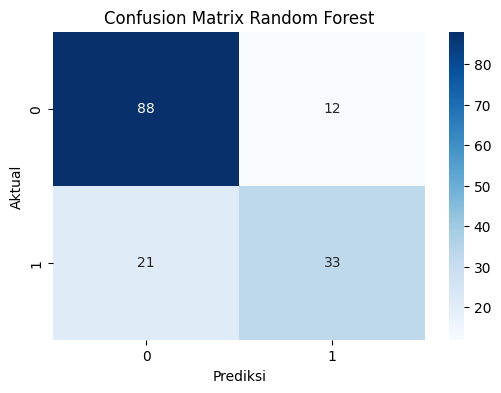

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.title("Confusion Matrix Random Forest")

plt.show()

In [29]:
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [27]:
# Menyimpan File

import joblib

joblib.dump(rf, "Model_random_forsest_diabetes.pkl")
joblib.dump(scaler, "scaler_diabetes.pkl")

['scaler_diabetes.pkl']